# Calcium Imaging Pipeline
**Modes:**
- `SINGLE_FILE = True` → load only the first `.ome.tif` chunk (laptop / dev)
- `SINGLE_FILE = False` → full recording (workstation)
- `USE_GPU = True` → CuPy acceleration — `pip install cupy-cuda12x` (adjust cuda version to match yours)

In [45]:
# ── CONFIG ───────────────────────────────────────────────────────────────────
EXPERIMENT_DIR  = r"Z:\ephacoffice\DColameo\Ca_Anand_AllData\07_11_25_Min6WT_Binning2_2_250ms_Exp3"

SINGLE_FILE     = True
USE_GPU         = False

SOURCE_FPS      = 4
TARGET_FPS      = 1
SPATIAL_BINNING = 2

# Segmentation base image:
#   'mean'     — average brightness
#   'std'      — temporal fluctuation only
#   'combined' — mean × std
#   'max'      — brightest frame each pixel ever reached (catches rarely-firing cells)
#   'max_std'  — max × std: bright at peak AND fluctuating (recommended)
SEG_IMAGE          = 'max_std'

GAUSS_SIGMA        = 2.0
MIN_PEAK_DISTANCE  = 8
MIN_CELL_AREA      = 10
MAX_CELL_AREA      = 1000

THRESH_METHOD   = 'li'
MANUAL_THRESH   = None
# ─────────────────────────────────────────────────────────────────────────────

In [7]:
import re, json
from pathlib import Path

import numpy as np
import tifffile
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import filters, morphology, measure, segmentation, feature
from skimage.color import label2rgb

# ── GPU / CPU backend ────────────────────────────────────────────────────────
if USE_GPU:
    try:
        import cupy as xp
        xp.array([1])  # trigger device init
        props = xp.cuda.runtime.getDeviceProperties(0)
        mem_gb = xp.cuda.Device(0).mem_info[1] / 1e9
        print(f"GPU: {props['name'].decode()}  ({mem_gb:.1f} GB VRAM)  — CuPy active")
    except Exception as e:
        print(f"CuPy unavailable ({e}) — falling back to CPU")
        import numpy as xp
        USE_GPU = False
else:
    xp = np
    print("CPU mode (numpy)")

def to_cpu(a):
    return xp.asnumpy(a) if USE_GPU else np.asarray(a)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

CPU mode (numpy)


## Step 1 — Discover files

In [8]:
exp_dir = Path(EXPERIMENT_DIR)

def _num_key(p):
    return tuple(int(n) for n in re.findall(r'\d+', p.name))

segment_dirs = sorted(
    [d for d in exp_dir.iterdir() if d.is_dir() and not d.name.startswith('40')],
    key=_num_key
)

all_tifs = []
for seg in segment_dirs:
    all_tifs.extend(sorted(seg.glob('*.ome.tif'), key=_num_key))

print(f"Experiment : {exp_dir.name}")
print(f"Segments   : {len(segment_dirs)}")
print(f"Total TIFs : {len(all_tifs)}")
for t in all_tifs:
    print(f"  {t.parent.name}/{t.name}")

tifs_to_load = all_tifs[:1] if SINGLE_FILE else all_tifs
print(f"\n{'[SINGLE FILE]' if SINGLE_FILE else '[FULL RECORDING]'} Loading {len(tifs_to_load)} file(s)")

Experiment : 07_11_25_Min6WT_Binning2_2_250ms_Exp3
Segments   : 4
Total TIFs : 9
  1_1/1_1_MMStack_Default.ome.tif
  1_2/1_2_MMStack_Default.ome.tif
  1_2/1_2_MMStack_Default_1.ome.tif
  1_3/1_3_MMStack_Default.ome.tif
  1_3/1_3_MMStack_Default_1.ome.tif
  1_3/1_3_MMStack_Default_2.ome.tif
  1_4/1_4_MMStack_Default.ome.tif
  1_4/1_4_MMStack_Default_1.ome.tif
  1_4/1_4_MMStack_Default_2.ome.tif

[SINGLE FILE] Loading 1 file(s)


## Step 2 — Inspect first file

In [9]:
with tifffile.TiffFile(tifs_to_load[0]) as tf:
    s = tf.asarray()
    print(f"File   : {tifs_to_load[0].name}")
    print(f"Shape  : {s.shape}   (frames × height × width)")
    print(f"Dtype  : {s.dtype}")
    print(f"Range  : {s.min()} – {s.max()}")
    print(f"Memory : {s.nbytes / 1e6:.0f} MB per file")
    try:
        meta = json.loads(tf.pages[0].description)
        iv = meta.get('Interval_ms') or meta.get('interval_ms')
        if iv:
            print(f"FPS (metadata): {1000/float(iv):.2f}")
    except Exception:
        pass

File   : 1_1_MMStack_Default.ome.tif
Shape  : (1200, 1100, 1600)   (frames × height × width)
Dtype  : uint16
Range  : 78 – 229
Memory : 4224 MB per file


## Steps 3–5 — Load, temporal downsample, spatial bin
Each chunk is downsampled and binned immediately after loading — only the reduced data is kept in memory.

Peak RAM = 1 raw chunk + accumulating downsampled movie, instead of the full recording at once.

In [10]:
ratio = SOURCE_FPS // TARGET_FPS

def _process_chunk(arr):
    """Temporal downsample + spatial bin a single (T, H, W) uint16 chunk."""
    # convert once, on GPU if available
    a = xp.asarray(arr.astype(np.float32))

    # temporal downsample — average every `ratio` frames
    T, H, W = a.shape
    T_trim = (T // ratio) * ratio
    a = a[:T_trim].reshape(T_trim // ratio, ratio, H, W).mean(axis=1)

    # spatial binning
    if SPATIAL_BINNING > 1:
        b = SPATIAL_BINNING
        T2, H2, W2 = a.shape
        Hb, Wb = H2 // b, W2 // b
        a = a[:, :Hb*b, :Wb*b].reshape(T2, Hb, b, Wb, b).mean(axis=(2, 4))

    return to_cpu(a)   # always return numpy so concatenation is on CPU

print(f"Loading {len(tifs_to_load)} file(s) — downsampling {ratio}x temporal"
      + (f", {SPATIAL_BINNING}x spatial" if SPATIAL_BINNING > 1 else "") + " per chunk ...")

processed = []
for p in tifs_to_load:
    raw_chunk = tifffile.imread(str(p))
    if raw_chunk.ndim == 2:
        raw_chunk = raw_chunk[np.newaxis]
    chunk_ds = _process_chunk(raw_chunk)
    del raw_chunk          # free original immediately
    processed.append(chunk_ds)
    print(f"  {p.parent.name}/{p.name}  {chunk_ds.shape}  ({chunk_ds.nbytes/1e6:.0f} MB kept)")

mov = np.concatenate(processed, axis=0)
del processed
print(f"\nMovie : {mov.shape}  ({mov.nbytes/1e9:.2f} GB total)")
print(f"Duration: {mov.shape[0] / TARGET_FPS:.1f} s  at {TARGET_FPS} FPS")

if USE_GPU:
    mov = xp.asarray(mov)
    print(f"Transferred to GPU ({mov.nbytes/1e6:.0f} MB VRAM)")

Loading 1 file(s) ...
  1_1/1_1_MMStack_Default.ome.tif  (1200, 1100, 1600)  4224 MB

Loaded  : (1200, 1100, 1600)  dtype=uint16
Duration: 300.0 s  (4.22 GB)


## Step 3b — Detect and remove bad frames
Plot per-frame mean intensity, flag frames below `LOW_SIGNAL_THRESH × median`, and drop them before any further processing.

In [ ]:
# Per-frame mean intensity (CPU for plotting)
frame_means = to_cpu(mov).mean(axis=(1, 2)) if USE_GPU else np.asarray(mov).mean(axis=(1, 2))
median_mean = np.median(frame_means)
threshold   = median_mean * LOW_SIGNAL_THRESH

bad_frames  = np.where(frame_means < threshold)[0]
good_frames = np.where(frame_means >= threshold)[0]

print(f"Median frame mean : {median_mean:.2f}")
print(f"Threshold         : {threshold:.2f}  ({LOW_SIGNAL_THRESH:.0%} of median)")
print(f"Bad frames        : {len(bad_frames)} / {len(frame_means)}")
if len(bad_frames):
    print(f"  Indices: {bad_frames.tolist()}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(frame_means, color='steelblue', lw=0.8, label='Frame mean intensity')
ax.axhline(threshold, color='red', lw=1.2, ls='--',
           label=f'Threshold ({LOW_SIGNAL_THRESH:.0%} of median = {threshold:.1f})')
if len(bad_frames):
    ax.scatter(bad_frames, frame_means[bad_frames], color='red', s=20,
               zorder=5, label=f'Bad frames (n={len(bad_frames)})')
ax.set_xlabel('Frame (post-downsample)')
ax.set_ylabel('Mean intensity')
ax.set_title('Per-frame mean intensity — red markers will be dropped')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── Drop bad frames ───────────────────────────────────────────────────────────
if len(bad_frames):
    if USE_GPU:
        mov = mov[xp.array(good_frames)]
    else:
        mov = mov[good_frames]
    print(f"\nAfter dropping: {mov.shape}  ({mov.shape[0] / TARGET_FPS:.1f} s)")
else:
    print("No bad frames detected — movie unchanged.")

## Step 6 — Summary projections
**Check here**: Std image should show bright blobs where cells are. If it looks flat, try lowering `SPATIAL_BINNING` to 1.

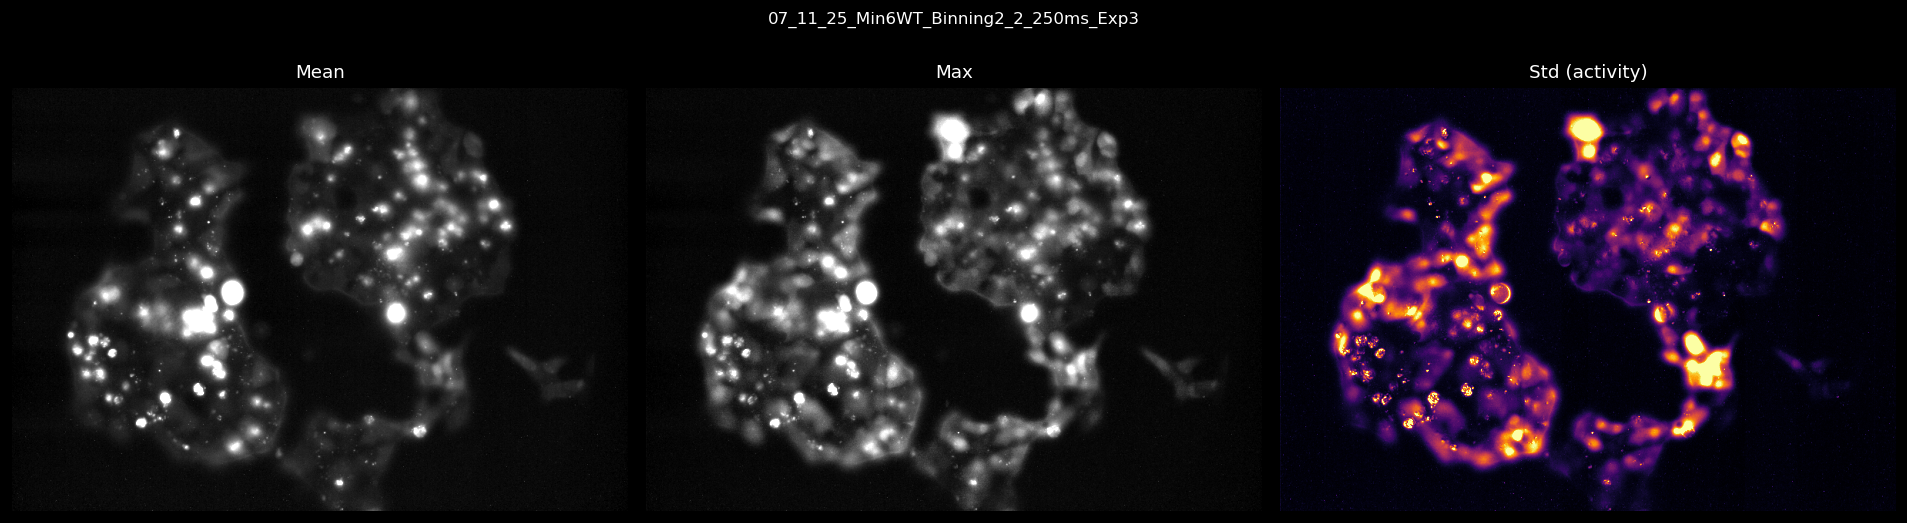

In [37]:
# Computed on GPU if enabled, then pulled to CPU for plotting
mean_img = to_cpu(mov.mean(axis=0)).astype(np.float32)
max_img  = to_cpu(mov.max(axis=0)).astype(np.float32)
std_img  = to_cpu(mov.std(axis=0)).astype(np.float32)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, img, title, cmap in zip(
    axes,
    [mean_img, max_img, std_img],
    ['Mean', 'Max', 'Std (activity)'],
    ['gray', 'gray', 'inferno']
):
    p1, p99 = np.percentile(img, [1, 99])
    ax.imshow(img, cmap=cmap, vmin=p1, vmax=p99)
    ax.set_title(title, fontsize=11)
    ax.axis('off')
plt.suptitle(exp_dir.name, fontsize=10)
plt.tight_layout()
plt.show()

## Step 7 — Cell segmentation  (CPU — only on summary image)
Tune `GAUSS_SIGMA`, `MIN_CELL_AREA`, `MAX_CELL_AREA` at the top and re-run this section.

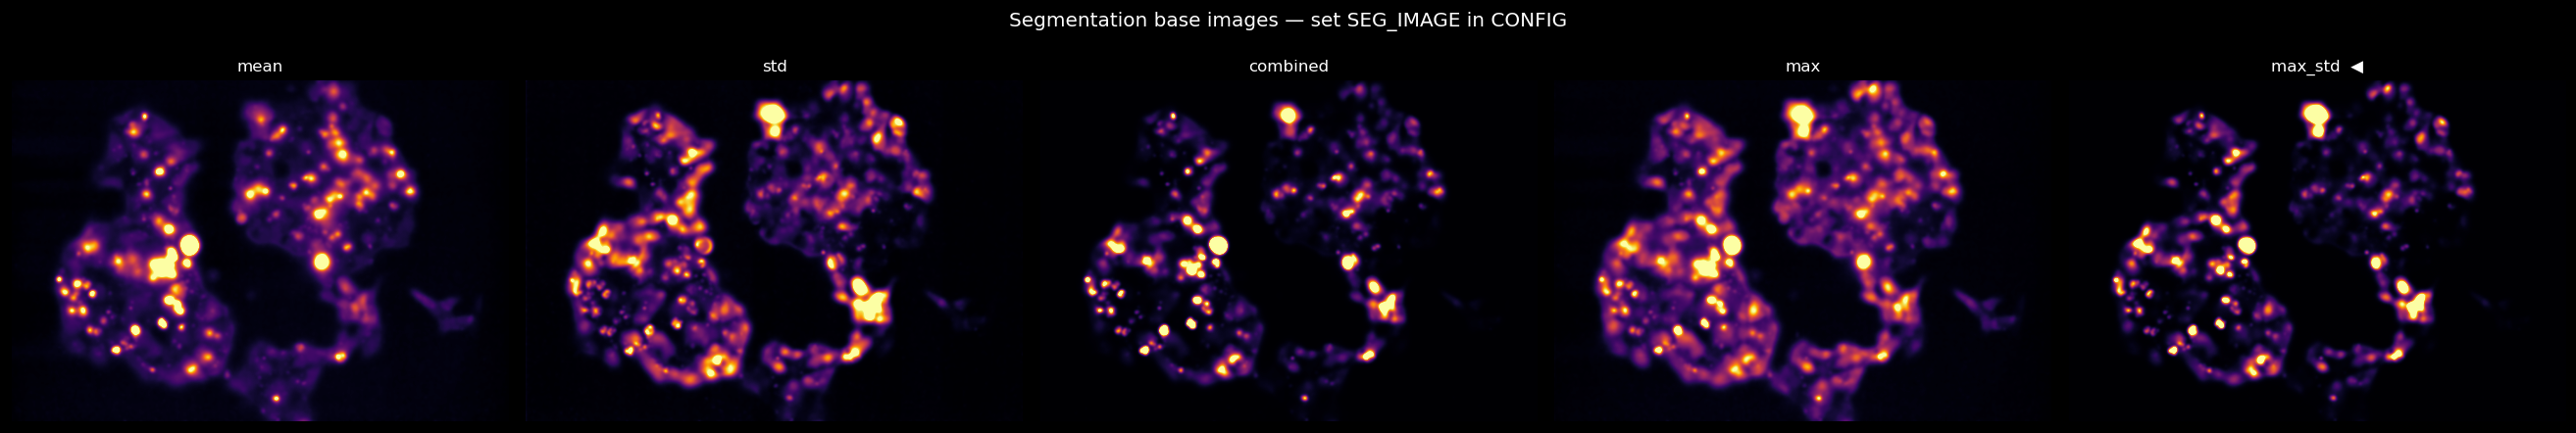

Li threshold (max_std): 0.014


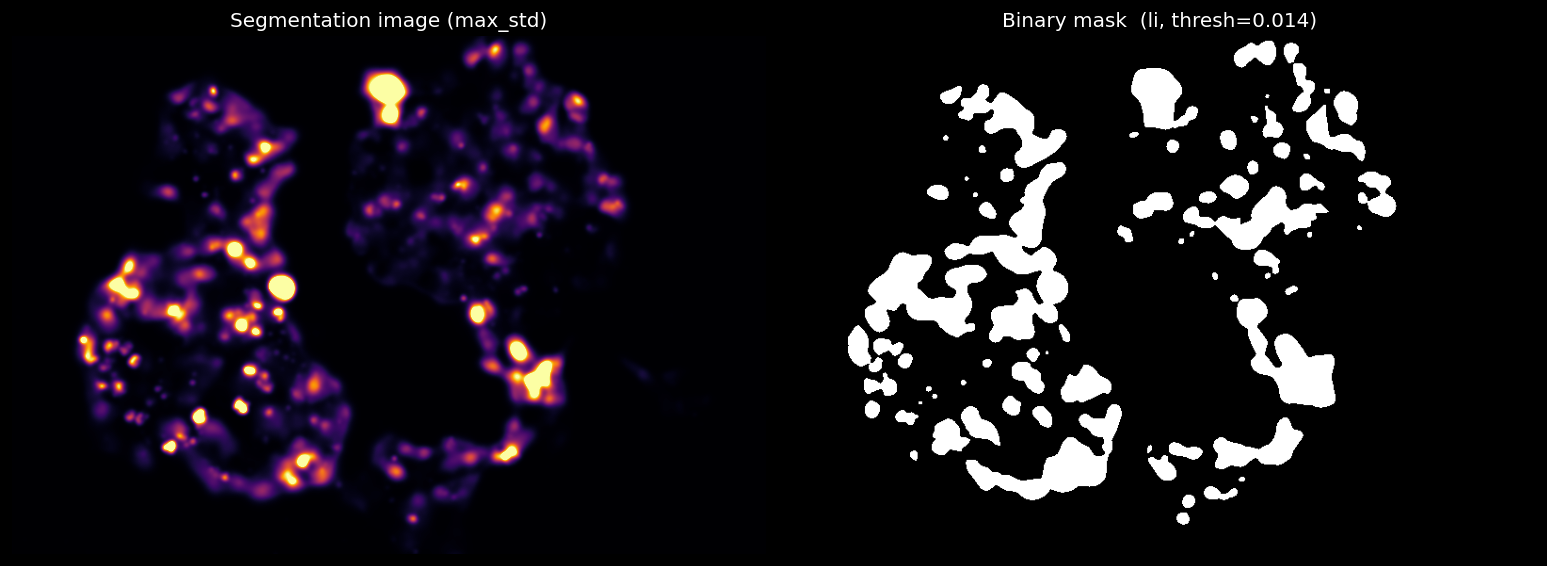

In [46]:
# ── Segmentation helpers (shared by sweep and final segmentation) ─────────────
_method_map = {
    'otsu'    : filters.threshold_otsu,
    'yen'     : filters.threshold_yen,
    'li'      : filters.threshold_li,
    'triangle': filters.threshold_triangle,
    'isodata' : filters.threshold_isodata,
}

def _build_seg(base):
    """Gaussian smooth + normalise to [0,1]."""
    s = filters.gaussian(base, sigma=GAUSS_SIGMA)
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

def _make_binary(seg, thresh):
    b = seg > thresh
    b = morphology.remove_small_objects(b, min_size=MIN_CELL_AREA)
    return ndimage.binary_fill_holes(b)

def _watershed_seg(seg, binary):
    """Watershed on -seg using local maxima of seg as seeds."""
    lm = feature.peak_local_max(
        seg * binary.astype(float), min_distance=MIN_PEAK_DISTANCE, labels=binary)
    mk = np.zeros_like(binary, dtype=int)
    if len(lm):
        mk[tuple(lm.T)] = 1
    mk = measure.label(mk)
    return segmentation.watershed(-seg, mk, mask=binary)

def _label_rois(labels):
    """Area-filter watershed labels, re-index from 1. Returns roi_mask."""
    roi = np.zeros_like(labels)
    valid = [p.label for p in measure.regionprops(labels)
             if MIN_CELL_AREA <= p.area <= MAX_CELL_AREA]
    for new_id, old in enumerate(valid, 1):
        roi[labels == old] = new_id
    return roi

def run_segmentation(seg, binary):
    """Full pipeline: watershed → area filter → return (roi_mask, n_cells)."""
    labels  = _watershed_seg(seg, binary)
    roi     = _label_rois(labels)
    return roi, int(roi.max())

# ── Build base images ─────────────────────────────────────────────────────────
mean_norm = (mean_img - mean_img.min()) / (mean_img.max() - mean_img.min() + 1e-9)
std_norm  = (std_img  - std_img.min())  / (std_img.max()  - std_img.min()  + 1e-9)
max_norm  = (max_img  - max_img.min())  / (max_img.max()  - max_img.min()  + 1e-9)

_base_options = {
    'mean'    : mean_norm,
    'std'     : std_norm,
    'combined': mean_norm * std_norm,
    'max'     : max_norm,
    'max_std' : max_norm  * std_norm,
}
assert SEG_IMAGE in _base_options, f"SEG_IMAGE must be one of {list(_base_options)}"

# Preview all base images
fig, axes = plt.subplots(1, len(_base_options), figsize=(22, 4))
for ax, (name, img) in zip(axes, _base_options.items()):
    sm = _build_seg(img)
    p1, p99 = np.percentile(sm, [1, 99])
    ax.imshow(sm, cmap='inferno', vmin=p1, vmax=p99)
    ax.set_title(name + ('  ◀' if name == SEG_IMAGE else ''), fontsize=10)
    ax.axis('off')
plt.suptitle('Segmentation base images — set SEG_IMAGE in CONFIG', y=1.01)
plt.tight_layout()
plt.show()

# Build active seg_img and binary
seg_img = _build_seg(_base_options[SEG_IMAGE])

if MANUAL_THRESH is not None:
    thresh = float(MANUAL_THRESH)
    print(f"Manual threshold       : {thresh:.4f}")
else:
    assert THRESH_METHOD in _method_map, f"Unknown THRESH_METHOD '{THRESH_METHOD}'"
    thresh = _method_map[THRESH_METHOD](seg_img)
    print(f"{THRESH_METHOD.capitalize()} threshold ({SEG_IMAGE}): {thresh:.4f}")

binary = _make_binary(seg_img, thresh)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
p1, p99 = np.percentile(seg_img, [1, 99])
axes[0].imshow(seg_img, cmap='inferno', vmin=p1, vmax=p99)
axes[0].set_title(f'Segmentation image ({SEG_IMAGE})')
axes[0].axis('off')
axes[1].imshow(binary, cmap='gray')
axes[1].set_title(f'Binary mask  ({THRESH_METHOD}, thresh={thresh:.4f})')
axes[1].axis('off')
plt.tight_layout()
plt.show()


── MEAN ─────────────────────────────────


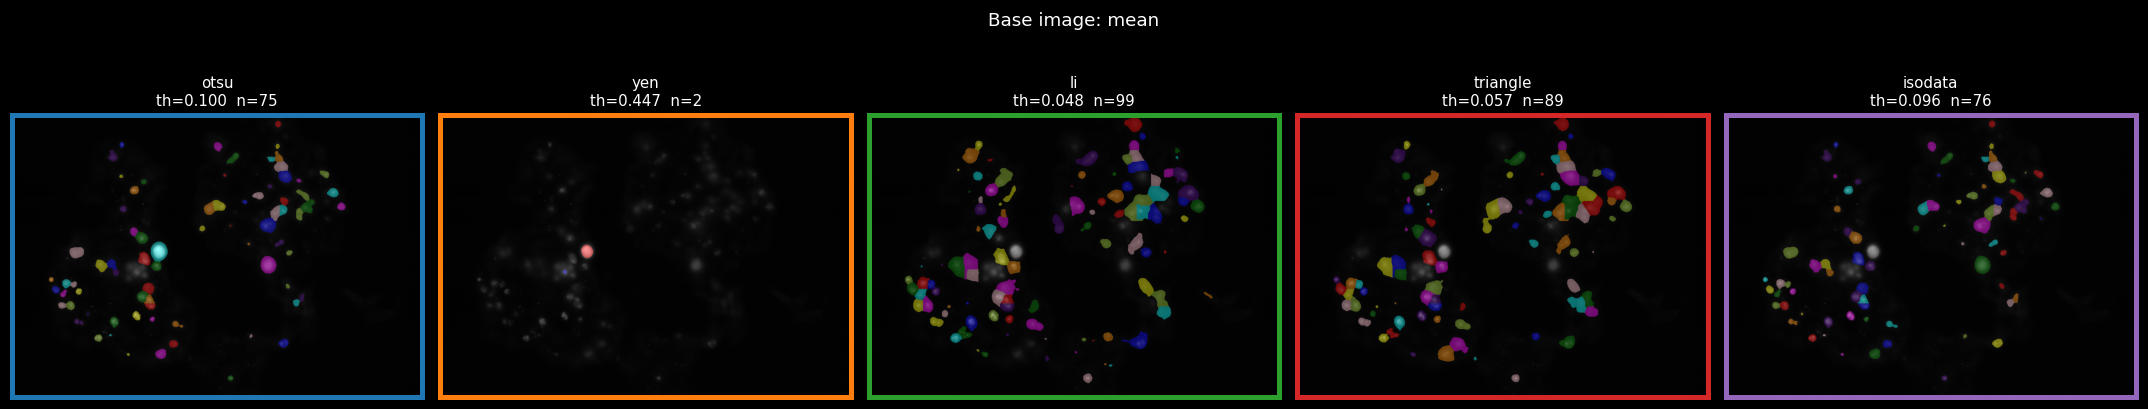


── STD ─────────────────────────────────


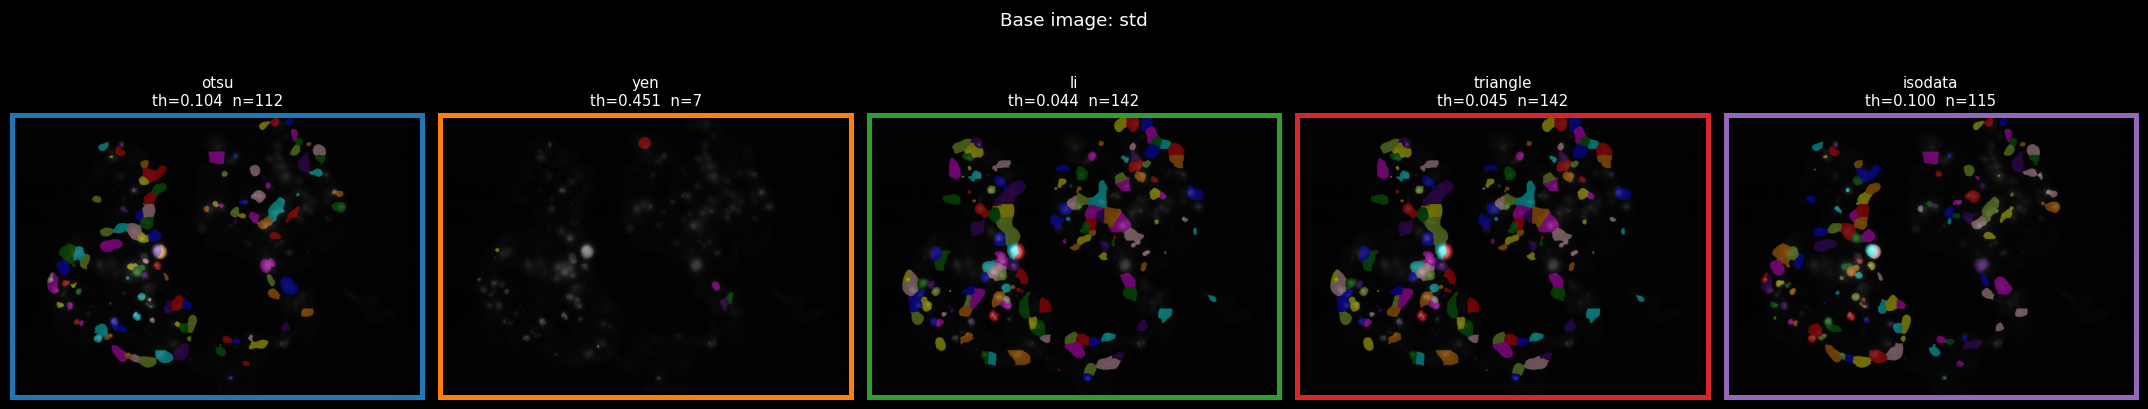


── COMBINED ─────────────────────────────────


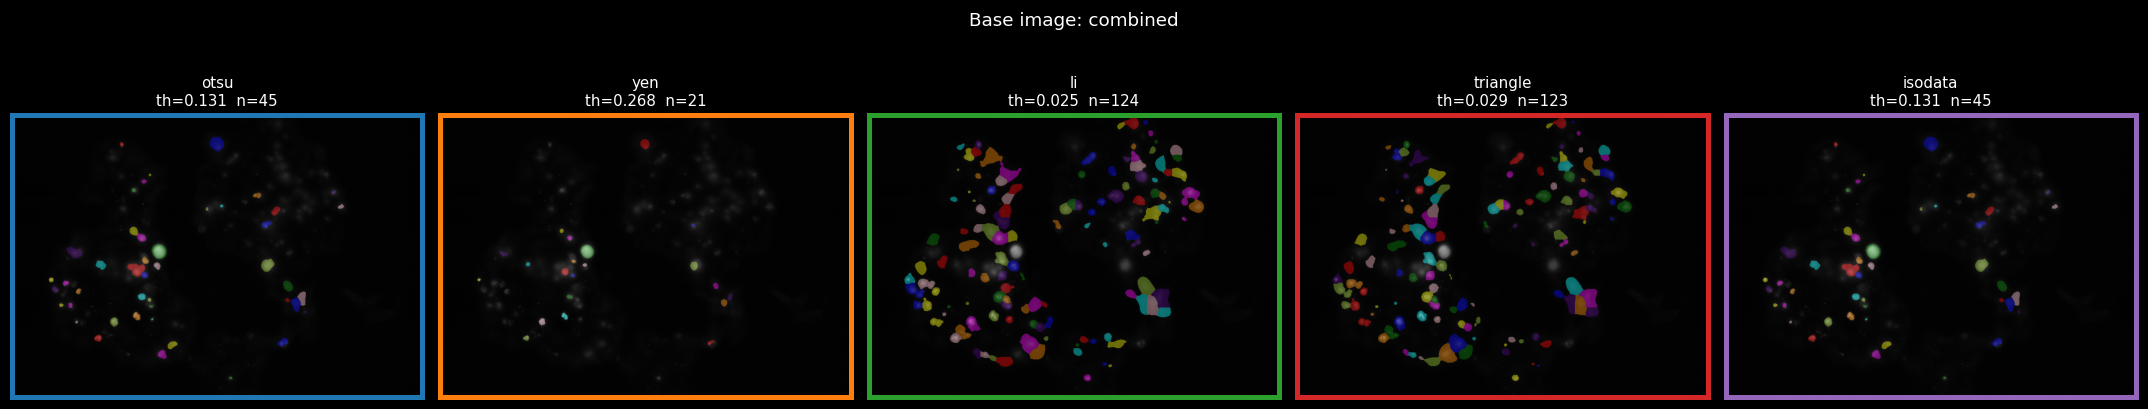


── MAX ─────────────────────────────────


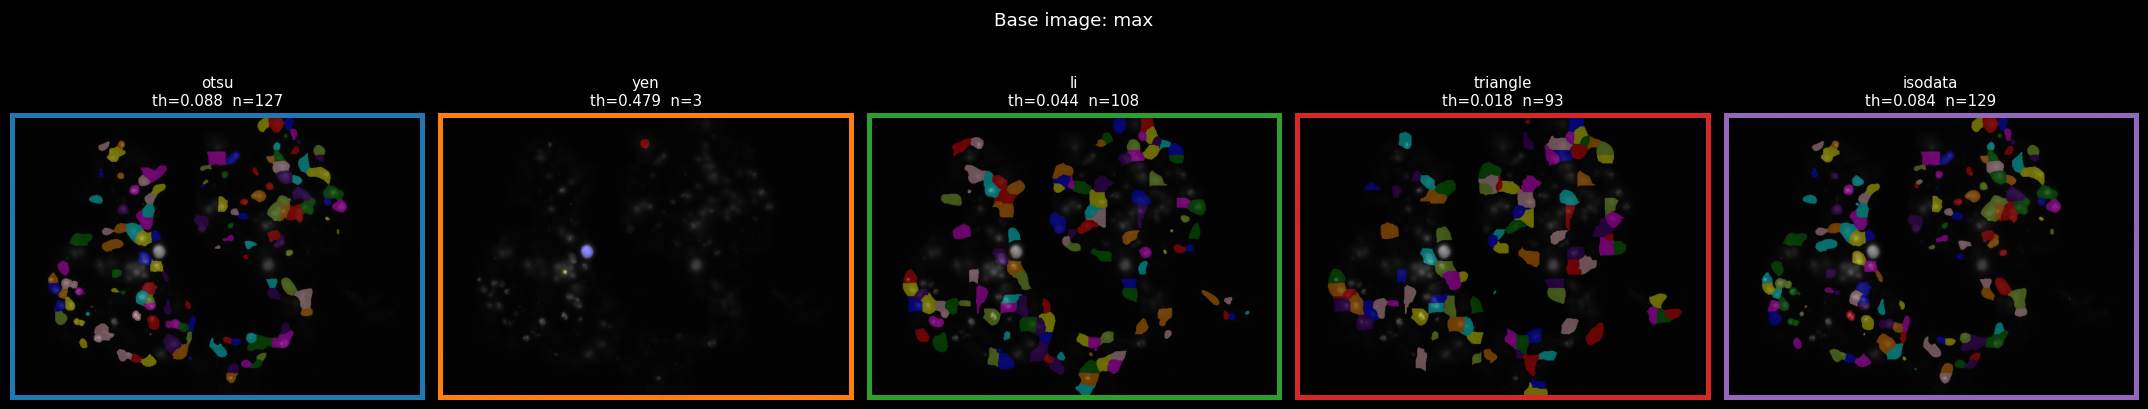


── MAX_STD ─────────────────────────────────


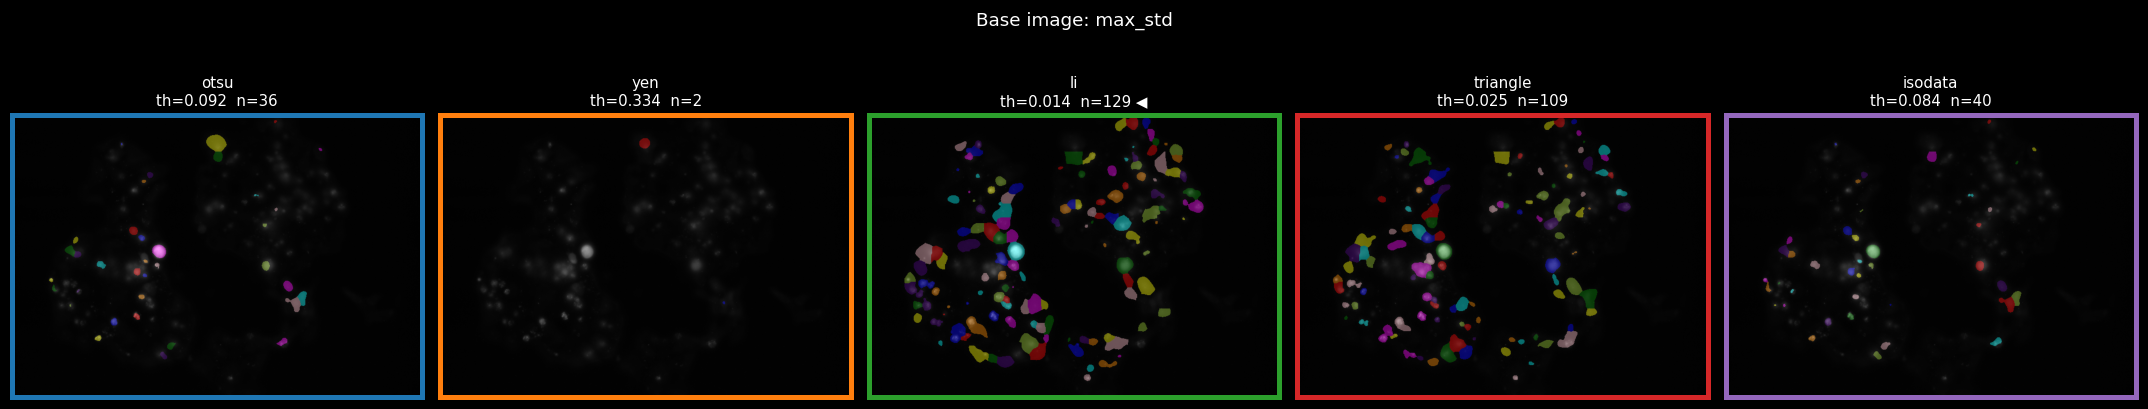

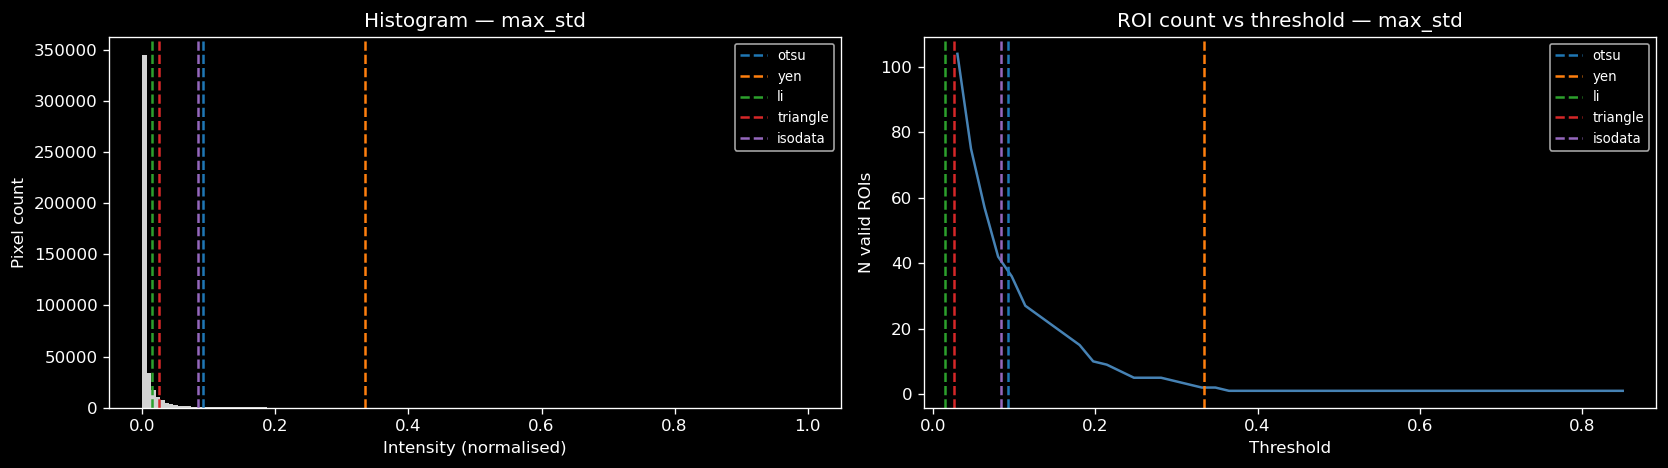


→ Tune SEG_IMAGE, THRESH_METHOD, MIN_PEAK_DISTANCE in CONFIG then re-run cells 16 and 18


In [47]:
# ── Threshold optimisation sweep ─────────────────────────────────────────────
# Uses the same helper functions as the final segmentation — results are identical.
_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

base_imgs = {name: _build_seg(base) for name, base in _base_options.items()}

# For each base image: show all 5 threshold methods
for base_name, seg_i in base_imgs.items():
    fig, axes = plt.subplots(1, len(_method_map), figsize=(18, 4))
    for ax, (mname, mfn), col in zip(axes, _method_map.items(), _colors):
        th      = mfn(seg_i)
        b       = _make_binary(seg_i, th)
        rm, n   = run_segmentation(seg_i, b)
        mean_norm_disp = mean_norm
        ov      = np.clip(label2rgb(rm, image=mean_norm_disp, bg_label=0, alpha=0.4), 0, 1)
        ax.imshow(ov)
        active  = ' ◀' if (base_name == SEG_IMAGE and
                           MANUAL_THRESH is None and mname == THRESH_METHOD) else ''
        ax.set_title(f"{mname}\nth={th:.3f}  n={n}{active}", fontsize=9)
        for spine in ax.spines.values():
            spine.set_edgecolor(col); spine.set_linewidth(3)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    plt.suptitle(f'Base image: {base_name}', y=1.01, fontsize=11)
    plt.tight_layout()
    plt.show()

# ROI-count vs threshold curve for the active base image
seg_active  = base_imgs[SEG_IMAGE]
thresholds  = np.linspace(0.03, 0.85, 50)
n_sweep     = [run_segmentation(seg_active, _make_binary(seg_active, th))[1]
               for th in thresholds]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(seg_active.ravel(), bins=150, color='lightgray', edgecolor='none')
for (mname, mfn), col in zip(_method_map.items(), _colors):
    axes[0].axvline(mfn(seg_active), color=col, lw=1.5, ls='--', label=mname)
if MANUAL_THRESH is not None:
    axes[0].axvline(MANUAL_THRESH, color='black', lw=2, label='manual')
axes[0].set_xlabel('Intensity (normalised)'); axes[0].set_ylabel('Pixel count')
axes[0].set_title(f'Histogram — {SEG_IMAGE}'); axes[0].legend(fontsize=8)

axes[1].plot(thresholds, n_sweep, '-', color='steelblue', lw=1.5)
for (mname, mfn), col in zip(_method_map.items(), _colors):
    axes[1].axvline(mfn(seg_active), color=col, lw=1.5, ls='--', label=mname)
if MANUAL_THRESH is not None:
    axes[1].axvline(MANUAL_THRESH, color='black', lw=2, label='manual')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('N valid ROIs')
axes[1].set_title(f'ROI count vs threshold — {SEG_IMAGE}'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()
print("\n→ Tune SEG_IMAGE / THRESH_METHOD / MANUAL_THRESH in CONFIG, re-run cells 14 and 16")

ROIs : 129  (MIN_PEAK_DISTANCE=8)
 Cell         y         x    area
--------------------------------
    1      17.0     512.3     480
    2      16.5     539.2     258
    3      20.3     489.8     386
    4      39.1     548.6     260
    5      53.5     557.8     165
    6      58.8     212.0     175
    7      57.9     577.6      29
    8      63.5     514.0      14
    9      62.6     178.3     290
   10      69.8     597.6     455
   11      70.5     551.1     296
   12      72.4     205.6     420
   13      85.6     428.8     292
   14      82.2     194.4     169
   15      84.7     398.8     821
   16      84.4     517.2     149
   17      85.5     599.9     242
   18      87.8     500.4      42
   19      96.1     568.6     709
   20      99.5     520.2     295
   21     104.4     372.3      47
   22     107.7     172.4      27
   23     113.2     592.3     452
   24     109.8     472.8     301
   25     116.5     413.7     150
   26     120.6     611.5     225
   27     120.9

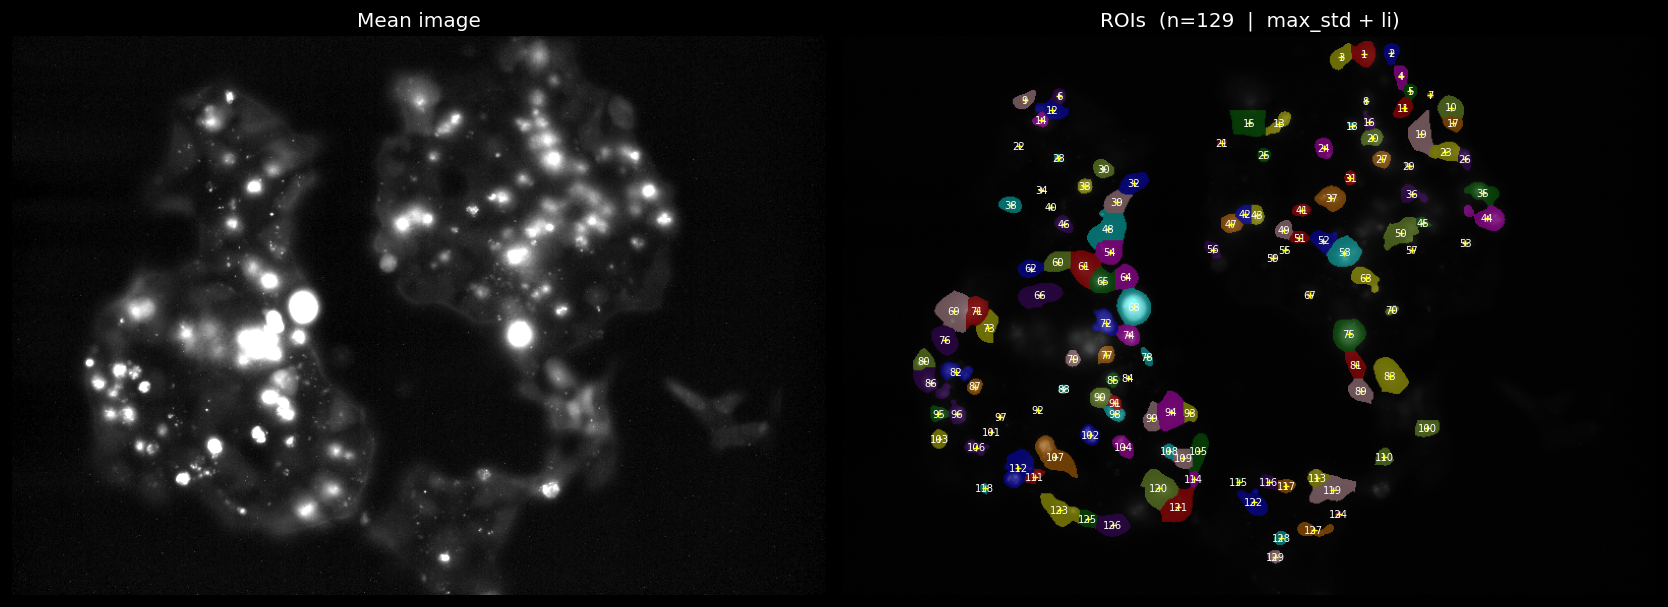

In [48]:
# 7c — final segmentation (same code path as the sweep ◀ panel)
roi_mask, n_cells = run_segmentation(seg_img, binary)

rprops    = measure.regionprops(roi_mask)
centroids = np.array([[rp.centroid[0], rp.centroid[1]] for rp in rprops])

print(f"ROIs : {n_cells}  (SEG_IMAGE={SEG_IMAGE}, {THRESH_METHOD}, thresh={thresh:.4f})")
print(f"{'Cell':>5}  {'y':>8}  {'x':>8}  {'area':>6}")
print("-" * 32)
for rp in rprops:
    print(f"{rp.label:>5}  {rp.centroid[0]:>8.1f}  {rp.centroid[1]:>8.1f}  {rp.area:>6}")

mean_norm_disp = mean_norm
overlay = np.clip(label2rgb(roi_mask, image=mean_norm_disp, bg_label=0, alpha=0.4), 0, 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
p1, p99   = np.percentile(mean_img, [1, 99])
axes[0].imshow(mean_img, cmap='gray', vmin=p1, vmax=p99)
axes[0].set_title('Mean image'); axes[0].axis('off')
axes[1].imshow(overlay)
axes[1].set_title(f'ROIs  (n={n_cells}  |  {SEG_IMAGE} + {THRESH_METHOD}  thresh={thresh:.4f})')
axes[1].axis('off')
for rp in rprops:
    y, x = rp.centroid
    axes[1].text(x, y, str(rp.label), color='white', fontsize=6, ha='center', va='center')
    axes[1].plot(x, y, '+', color='yellow', ms=4, mew=0.8)
plt.tight_layout()
plt.show()

## Step 8 — Extract fluorescence traces
Index gather runs on GPU (if enabled) for speed.

F matrix: (129, 300)  (cells × frames)


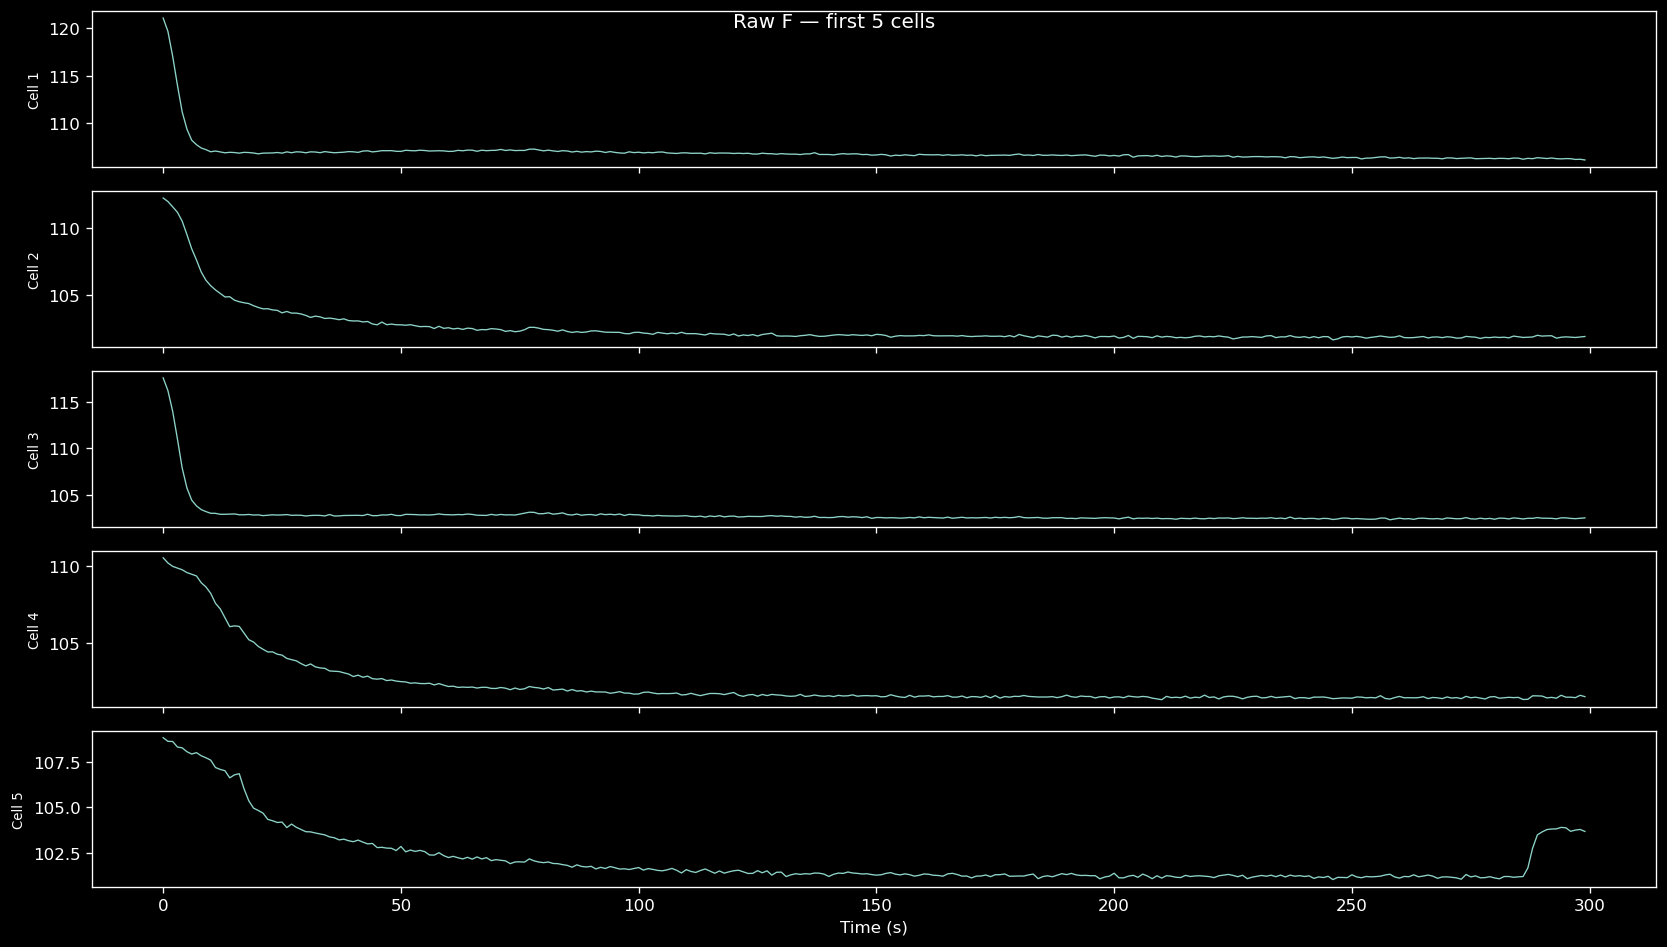

In [49]:
T_final   = mov.shape[0]
time_axis = np.arange(T_final) / TARGET_FPS   # seconds
rprops    = measure.regionprops(roi_mask)

F = np.zeros((n_cells, T_final), dtype=np.float32)
for i, rp in enumerate(rprops):
    ys, xs = np.where(roi_mask == rp.label)
    if USE_GPU:
        ys_g, xs_g = xp.array(ys), xp.array(xs)
        F[i] = to_cpu(mov[:, ys_g, xs_g].mean(axis=1))
    else:
        F[i] = mov[:, ys, xs].mean(axis=1)

print(f"F matrix: {F.shape}  (cells × frames)")

fig, axes = plt.subplots(min(5, n_cells), 1, figsize=(14, 8), sharex=True)
if n_cells == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.plot(time_axis, F[i], lw=0.8)
    ax.set_ylabel(f'Cell {i+1}', fontsize=8)
axes[-1].set_xlabel('Time (s)')
plt.suptitle('Raw F — first 5 cells')
plt.tight_layout()
plt.show()

## Step 9 — dF/F
Rolling 8th-percentile baseline over a 60-s window (robust to transients).  
Tune `baseline_window_s` if you see a drifting baseline.

In [50]:
def compute_dff(F, fps, baseline_window_s=60, pct=8):
    win = max(1, int(baseline_window_s * fps))
    n, T = F.shape
    F0 = np.zeros_like(F)
    for i in range(n):
        for t in range(T):
            lo, hi = max(0, t - win//2), min(T, t + win//2 + 1)
            F0[i, t] = np.percentile(F[i, lo:hi], pct)
    return (F - F0) / (F0 + 1e-6), F0

print("Computing dF/F ...")
dff, F0 = compute_dff(F, TARGET_FPS)
print(f"dF/F: {dff.shape}")

Computing dF/F ...
dF/F: (129, 300)


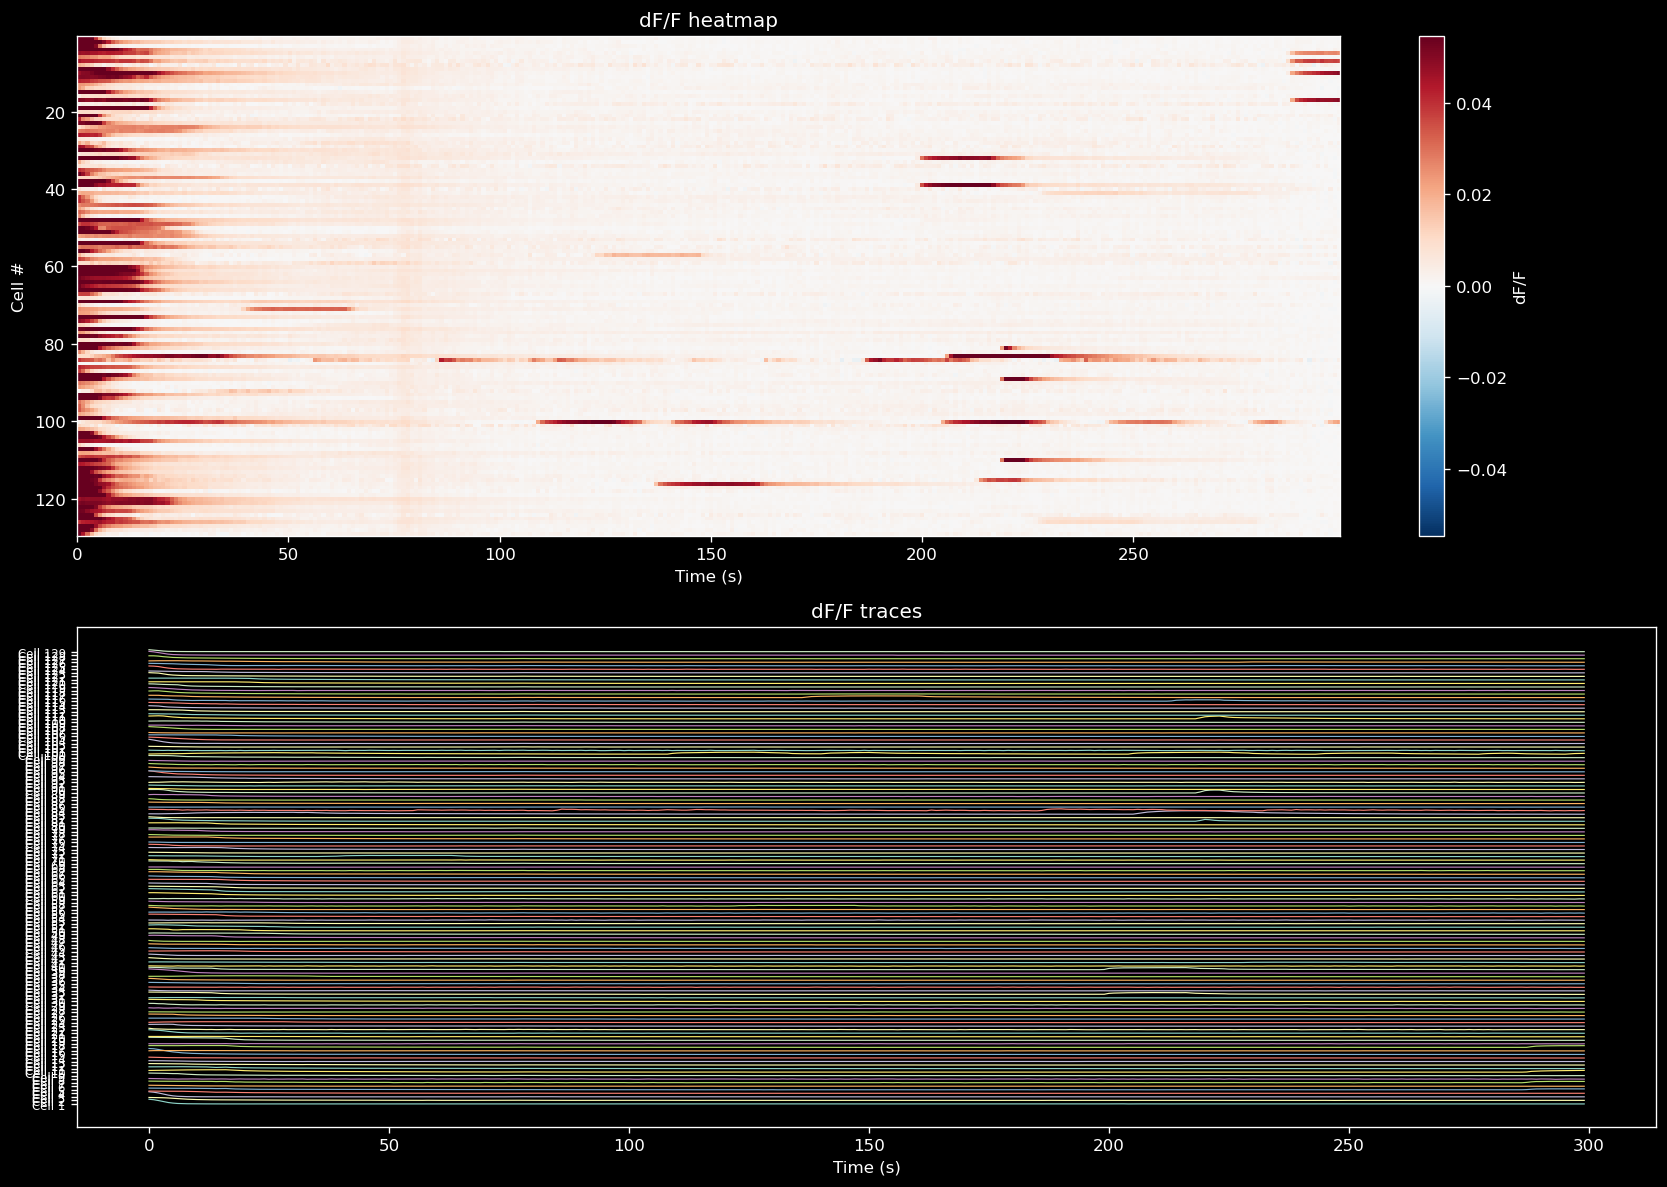

In [51]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

vmax = np.percentile(np.abs(dff), 99)
im = axes[0].imshow(dff, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                    extent=[0, time_axis[-1], n_cells + 0.5, 0.5])
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Cell #')
axes[0].set_title('dF/F heatmap')
plt.colorbar(im, ax=axes[0], label='dF/F')

step = max(np.percentile(np.abs(dff), 95) * 3, 0.1)
for i in range(n_cells):
    axes[1].plot(time_axis, dff[i] + i * step, lw=0.7)
axes[1].set_xlabel('Time (s)')
axes[1].set_title('dF/F traces')
axes[1].set_yticks(np.arange(n_cells) * step)
axes[1].set_yticklabels([f'Cell {i+1}' for i in range(n_cells)], fontsize=7)
plt.tight_layout()
plt.show()

## Step 10 — Save

In [ ]:
tag     = '_single' if SINGLE_FILE else ''
out_dir = exp_dir / f'pipeline_output{tag}'
out_dir.mkdir(exist_ok=True)

np.save(out_dir / 'roi_mask.npy',  roi_mask)
np.save(out_dir / 'centroids.npy', centroids)
np.save(out_dir / 'F_raw.npy',     F)
np.save(out_dir / 'dff.npy',       dff)
np.save(out_dir / 'time_axis.npy', time_axis)
tifffile.imwrite(str(out_dir / 'mean_image.tif'), mean_img)


import csv
with open(out_dir / 'centroids.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['cell_id', 'y_pixel', 'x_pixel', 'area_px'])
    for rp in rprops:
        w.writerow([rp.label, round(rp.centroid[0], 2), round(rp.centroid[1], 2), rp.area])

print(f"Saved → {out_dir}")
for name, arr in [('roi_mask', roi_mask), ('centroids', centroids),
                  ('F_raw', F), ('dff', dff), ('time_axis', time_axis)]:
    print(f"  {name}.npy        {arr.shape}")
print(f"  centroids.csv        ({n_cells} rows)")

## Step 11 — Generate annotated video
`mov` is still in memory — render the MP4 now and discard it. No TIFF needed.

In [ ]:
import matplotlib.gridspec as gridspec
import matplotlib.animation as animation
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from skimage.segmentation import find_boundaries

VIDEO_FPS        = 5      # playback speed
DFF_VMAX         = 1.0    # dF/F colormap saturation
MAX_VIDEO_FRAMES = None   # int to cap length, None = all frames

# ── Pre-compute ROI boundary pixels ──────────────────────────────────────────
boundary_pixels = []
for rp in rprops:
    mask = (roi_mask == rp.label)
    boundary_pixels.append(np.where(find_boundaries(mask, mode='outer')))

act_cmap    = cm.get_cmap('RdYlGn')
act_norm    = Normalize(vmin=-DFF_VMAX, vmax=DFF_VMAX)
mov_cpu     = to_cpu(mov)   # ensure numpy for indexing
p1_v, p99_v = np.percentile(mov_cpu, [1, 99])
n_frames    = len(time_axis) if MAX_VIDEO_FRAMES is None else min(MAX_VIDEO_FRAMES, len(time_axis))
H_v, W_v   = mov_cpu.shape[1], mov_cpu.shape[2]

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(11, 11 * (H_v/W_v + 0.45)))
gs  = gridspec.GridSpec(2, 1, height_ratios=[H_v/W_v, 0.4 * H_v/W_v], hspace=0.08)
ax_mov   = fig.add_subplot(gs[0])
ax_trace = fig.add_subplot(gs[1])

frame0_norm = np.clip((mov_cpu[0] - p1_v) / (p99_v - p1_v + 1e-9), 0, 1)
im_mov   = ax_mov.imshow(np.stack([frame0_norm]*3, axis=-1), interpolation='nearest')
time_txt = ax_mov.text(0.02, 0.97, '', transform=ax_mov.transAxes,
                       color='white', fontsize=10, va='top',
                       bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))
ax_mov.axis('off')

ax_trace.imshow(dff[:, :n_frames], aspect='auto', cmap='RdBu_r',
                vmin=-DFF_VMAX, vmax=DFF_VMAX,
                extent=[time_axis[0], time_axis[n_frames-1], n_cells+0.5, 0.5])
ax_trace.set_xlabel('Time (s)', fontsize=9)
ax_trace.set_ylabel('Cell #', fontsize=9)
ax_trace.set_yticks(np.arange(1, n_cells+1, max(1, n_cells//10)))
cursor = ax_trace.axvline(time_axis[0], color='yellow', lw=1.5)

def _update(t):
    fn = np.clip((mov_cpu[t] - p1_v) / (p99_v - p1_v + 1e-9), 0, 1)
    rgb = np.stack([fn]*3, axis=-1).copy()
    for i, (ys, xs) in enumerate(boundary_pixels):
        rgb[ys, xs] = act_cmap(act_norm(dff[i, t]))[:3]
    im_mov.set_data(rgb)
    time_txt.set_text(f't = {time_axis[t]:.0f} s')
    cursor.set_xdata([time_axis[t], time_axis[t]])
    return im_mov, time_txt, cursor

anim = animation.FuncAnimation(fig, _update, frames=n_frames,
                                interval=1000/VIDEO_FPS, blit=True)

mp4_path = out_dir / 'ca_video.mp4'
writer   = animation.FFMpegWriter(fps=VIDEO_FPS, bitrate=2000,
                                  extra_args=['-vcodec', 'libx264', '-pix_fmt', 'yuv420p'])
anim.save(str(mp4_path), writer=writer)
plt.close(fig)
print(f"Saved → {mp4_path}  ({mp4_path.stat().st_size/1e6:.1f} MB)")